# K-means Clustering

In this this exercise, you will implement the K-means algorithm and use it for image compression.

* You will start with a sample dataset that will help you gain an intuition of how the K-means algorithm works.
* After that, you wil use the K-means algorithm for image compression by reducing the number of colors that occur in an image to only those that are most common in that image.




# Outline
- [ 1 - Implementing K-means](#1)
  - [ 1.1 Finding closest centroids](#1.1)
    - [ Exercise 1](#ex01)
  - [ 1.2 Computing centroid means](#1.2)
    - [ Exercise 2](#ex02)
- [ 2 - K-means on a sample dataset ](#2)
- [ 3 - Random initialization](#3)
- [ 4 - Image compression with K-means](#4)
  - [ 4.1 Dataset](#4.1)
  - [ 4.2 K-Means on image pixels](#4.2)
  - [ 4.3 Compress the image](#4.3)


In [46]:
from google.colab import drive
drive.mount('/content/drive')
import sys
sys.path.append('/content/drive/MyDrive/Assignments-MS/AS_2/Part-A')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [47]:
folder_path = '/content/drive/MyDrive/Assignments-MS/AS_2/Part-A'
import os

# List files in the As_2 folder
for file in os.listdir(folder_path):
    print(file)


utils.py
public_tests.py
__pycache__
images
data
Assignment-2-part-A.ipynb


In [48]:
import numpy as np
import matplotlib.pyplot as plt
utils = '/content/drive/MyDrive/Assignments-MS/AS_2/Part-A/utils.py'

from utils import *

%matplotlib inline


<a name="1"></a>
## 1 - Implementing K-means

The K-means algorithm is a method to automatically cluster similar
data points together.

* Concretely, you are given a training set $\{x^{(1)}, ..., x^{(m)}\}$, and you want
to group the data into a few cohesive “clusters”.


* K-means is an iterative procedure that
     * Starts by guessing the initial centroids, and then
     * Refines this guess by
         * Repeatedly assigning examples to their closest centroids, and then
         * Recomputing the centroids based on the assignments.
         

* In pseudocode, the K-means algorithm is as follows:

    ``` python
    # Initialize centroids
    # K is the number of clusters
    centroids = kMeans_init_centroids(X, K)
    
    for iter in range(iterations):
        # Cluster assignment step:
        # Assign each data point to the closest centroid.
        # idx[i] corresponds to the index of the centroid
        # assigned to example i
        idx = find_closest_centroids(X, centroids)

        # Move centroid step:
        # Compute means based on centroid assignments
        centroids = compute_means(X, idx, K)
    ```


* The inner-loop of the algorithm repeatedly carries out two steps:
    * (i) Assigning each training example $x^{(i)}$ to its closest centroid, and
    * (ii) Recomputing the mean of each centroid using the points assigned to it.
    
    
* The $K$-means algorithm will always converge to some final set of means for the centroids.

* However, that the converged solution may not always be ideal and depends on the initial setting of the centroids.
    * Therefore, in practice the K-means algorithm is usually run a few times with different random initializations.
    * One way to choose between these different solutions from different random initializations is to choose the one with the lowest cost function value (distortion).

You will implement the two phases of the K-means algorithm separately
in the next sections.
* You will start by completing `find_closest_centroid` and then proceed to complete `compute_centroids`.

<a name="1.1"></a>
### 1.1 Finding closest centroids

In the “cluster assignment” phase of the K-means algorithm, the
algorithm assigns every training example $x^{(i)}$ to its closest
centroid, given the current positions of centroids.

<a name="ex01"></a>
### Exercise 1

Your task is to complete the code in `find_closest_centroids`.
* This function takes the data matrix `X` and the locations of all
centroids inside `centroids`
* It should output a one-dimensional array `idx` (which has the same number of elements as `X`) that holds the index  of the closest centroid (a value in $\{1,...,K\}$, where $K$ is total number of centroids) to every training example .
* Specifically, for every example $x^{(i)}$ we set
$$c^{(i)} := j \quad \mathrm{that \; minimizes} \quad ||x^{(i)} - \mu_j||^2,$$
where
 * $c^{(i)}$ is the index of the centroid that is closest to $x^{(i)}$ (corresponds to `idx[i]` in the starter code), and
 * $\mu_j$ is the position (value) of the $j$’th centroid. (stored in `centroids` in the starter code)

If you get stuck, you can check out the hints presented after the cell below to help you with the implementation.

In [49]:
# UNQ_C1
# GRADED FUNCTION: find_closest_centroids

def find_closest_centroids(X, centroids):
    """
    Computes the centroid memberships for every example

    Args:
        X (ndarray): (m, n) Input values
        centroids (ndarray): k centroids

    Returns:
        idx (array_like): (m,) closest centroids

    """

    # Set K
    K = centroids.shape[0]

    # You need to return the following variables correctly
    idx = np.zeros(X.shape[0], dtype=int)

    ### START CODE HERE ###

    for i in range(X.shape[0]):
          # Array to hold distance between X[i] and each centroids[j]
          distance = []
          for j in range(centroids.shape[0]):
              norm_ij = np.linalg.norm(X[i] - centroids[j])
              # Your code to calculate the norm between (X[i] - centroids[j])
              distance.append(norm_ij)

          idx[i]= np.argmin(distance)
           # Your code here to calculate index of minimum value in distance
    ### END CODE HERE ###

    return idx

<details>
  <summary><font size="3" color="darkgreen"><b>Click for hints</b></font></summary>
    
    
* Here's how you can structure the overall implementation for this function
    ```python
    def find_closest_centroids(X, centroids):
    
        # Set K
        K = centroids.shape[0]
    
        # You need to return the following variables correctly
        idx = np.zeros(X.shape[0], dtype=int)
    
        ### START CODE HERE ###
        for i in range(X.shape[0]):
            # Array to hold distance between X[i] and each centroids[j]
            distance = []
            for j in range(centroids.shape[0]):
                norm_ij = # Your code to calculate the norm between (X[i] - centroids[j])
                distance.append(norm_ij)
            
            idx[i] = # Your code here to calculate index of minimum value in distance
        ### END CODE HERE ###
        return idx
    ```
  
    If you're still stuck, you can check the hints presented below to figure out how to calculate `norm_ij` and `idx[i]`.
    
    <details>
          <summary><font size="2" color="darkblue"><b>Hint to calculate norm_ij</b></font></summary>
           &emsp; &emsp; You can use <a href="https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html">np.linalg.norm</a> to calculate the norm
          <details>
              <summary><font size="2" color="blue"><b>&emsp; &emsp; More hints to calculate norm_ij</b></font></summary>
               &emsp; &emsp; You can compute norm_ij as <code>norm_ij = np.linalg.norm(X[i] - centroids[j]) </code>
           </details>
    </details>

     <details>
          <summary><font size="2" color="darkblue"><b>Hint to calculate idx[i]</b></font></summary>
          &emsp; &emsp; You can use <a href="https://numpy.org/doc/stable/reference/generated/numpy.argmin.html">np.argmin</a> to find the index of the minimum value
          <details>
              <summary><font size="2" color="blue"><b>&emsp; &emsp; More hints to calculate idx[i]</b></font></summary>
              &emsp; &emsp; You can compute idx[i] as <code>idx[i] = np.argmin(distance)</code>
          </details>
    </details>
        
    </details>

</details>

    


Now let's check your implementation using an example dataset

In [50]:
# Load an example dataset that we will be using

def load_data():
    X = np.load("/content/drive/MyDrive/Assignments-MS/AS_2/Part-A/data/ex7_X.npy")
    return X

X=load_data()

The code below prints the first five elements in the variable `X` and the dimensions of the variable

In [51]:
print("First five elements of X are:\n", X[:5])
print('The shape of X is:', X.shape)

First five elements of X are:
 [[1.84207953 4.6075716 ]
 [5.65858312 4.79996405]
 [6.35257892 3.2908545 ]
 [2.90401653 4.61220411]
 [3.23197916 4.93989405]]
The shape of X is: (300, 2)


In [52]:
# Select an initial set of centroids (3 Centroids)
initial_centroids = np.array([[3,3], [6,2], [8,5]])

# Find closest centroids using initial_centroids
idx = find_closest_centroids(X, initial_centroids)

# Print closest centroids for the first three elements
print("First three elements in idx are:", idx[:3])

# UNIT TEST
# public_tests='/content/drive/MyDrive/Assignments-MS/AS_2/Part-A/public_tests.py'
from public_tests import *

find_closest_centroids_test(find_closest_centroids)


First three elements in idx are: [0 2 1]
All tests passed!


**Expected Output**:
<table>
  <tr>
    <td> <b>First three elements in idx are<b></td>
    <td> [0 2 1] </td>
  </tr>
</table>

<a name="1.2"></a>
### 1.2 Computing centroid means

Given assignments of every point to a centroid, the second phase of the
algorithm recomputes, for each centroid, the mean of the points that
were assigned to it.


<a name="ex02"></a>
### Exercise 2

Please complete the `compute_centroids` below to recompute the value for each centroid

* Specifically, for every centroid $\mu_k$ we set
$$\mu_k = \frac{1}{|C_k|} \sum_{i \in C_k} x^{(i)}$$

    where
    * $C_k$ is the set of examples that are assigned to centroid $k$
    * $|C_k|$ is the number of examples in the set $C_k$


* Concretely, if two examples say $x^{(3)}$ and $x^{(5)}$ are assigned to centroid $k=2$,
then you should update $\mu_2 = \frac{1}{2}(x^{(3)}+x^{(5)})$.

If you get stuck, you can check out the hints presented after the cell below to help you with the implementation.

In [53]:
# UNQ_C2
# GRADED FUNCTION: compute_centpods

def compute_centroids(X, idx, K):
    """
    Returns the new centroids by computing the means of the
    data points assigned to each centroid.

    Args:
        X (ndarray):   (m, n) Data points
        idx (ndarray): (m,) Array containing index of closest centroid for each
                       example in X. Concretely, idx[i] contains the index of
                       the centroid closest to example i
        K (int):       number of centroids

    Returns:
        centroids (ndarray): (K, n) New centroids computed
    """

    # Useful variables
    m, n = X.shape

    # You need to return the following variables correctly
    centroids = np.zeros((K, n))

    ### START CODE HERE ###
    for k in range(K):
          points =  X[idx == k]
          # Your code here to get a list of all data points in X assigned to centroid k
          centroids[k] =  np.mean(points, axis = 0)



    ### END CODE HERE ##

    return centroids

<details>
  <summary><font size="3" color="darkgreen"><b>Click for hints</b></font></summary>
    
    
* Here's how you can structure the overall implementation for this function
    ```python
    def compute_centroids(X, idx, K):
        # Useful variables
        m, n = X.shape
    
        # You need to return the following variables correctly
        centroids = np.zeros((K, n))
    
        ### START CODE HERE ###
        for k in range(K):   
            points = # Your code here to get a list of all data points in X assigned to centroid k  
            centroids[k] = # Your code here to compute the mean of the points assigned
    ### END CODE HERE ##
    
    return centroids
    ```
  
    If you're still stuck, you can check the hints presented below to figure out how to calculate `points` and `centroids[k]`.
    
    <details>
          <summary><font size="2" color="darkblue"><b>Hint to calculate points</b></font></summary>
           &emsp; &emsp; Say we wanted to find all the values in X that were assigned to cluster <code>k=0</code>. That is, the corresponding value in idx for these examples is 0. In Python, we can do it as <code>X[idx == 0]</code>. Similarly, the points assigned to centroid <code>k=1</code> are <code>X[idx == 1]</code>
          <details>
              <summary><font size="2" color="blue"><b>&emsp; &emsp; More hints to calculate points</b></font></summary>
               &emsp; &emsp; You can compute points as <code>points = X[idx == k] </code>
           </details>
    </details>

     <details>
          <summary><font size="2" color="darkblue"><b>Hint to calculate centroids[k]</b></font></summary>
          &emsp; &emsp; You can use <a href="https://numpy.org/doc/stable/reference/generated/numpy.mean.html">np.mean</a> to find the mean. Make sure to set the parameter <code>axis=0</code>
          <details>
              <summary><font size="2" color="blue"><b>&emsp; &emsp; More hints to calculate centroids[k]</b></font></summary>
              &emsp; &emsp; You can compute centroids[k] as <code>centroids[k] = np.mean(points, axis = 0)</code>
          </details>
    </details>
        
    </details>

</details>

    


Now check your implementation by running the cell below

In [54]:
K = 3
centroids = compute_centroids(X, idx, K)

print("The centroids are:", centroids)

# UNIT TEST
compute_centroids_test(compute_centroids)


The centroids are: [[2.42830111 3.15792418]
 [5.81350331 2.63365645]
 [7.11938687 3.6166844 ]]
All tests passed!


**Expected Output**:

2.42830111 3.15792418

5.81350331 2.63365645

7.11938687 3.6166844

<a name="2"></a>
## 2 - K-means on a sample dataset

After you have completed the two functions (`find_closest_centroids`
and `compute_centroids`) above, the next step is to run the
K-means algorithm on a toy 2D dataset to help you understand how
K-means works.
* We encourage you to take a look at the function (`run_kMeans`) below to understand how it works.
* Notice that the code calls the two functions you implemented in a loop.

When you run the code below, it will produce a
visualization that steps through the progress of the algorithm at
each iteration.
* At the end, your figure should look like the one displayed in Figure 1.

<img src="images/figure 1.png" width="500" height="500">


**Note**: You do not need to implement anything for this part. Simply run the code provided below

In [55]:
# You do not need to implement anything for this part

def run_kMeans(X, initial_centroids, max_iters=10, plot_progress=False):
    """
    Runs the K-Means algorithm on data matrix X, where each row of X
    is a single example
    """

    # Initialize values
    m, n = X.shape
    K = initial_centroids.shape[0]
    centroids = initial_centroids
    previous_centroids = centroids
    idx = np.zeros(m)

    # Run K-Means
    for i in range(max_iters):

        #Output progress
        print("K-Means iteration %d/%d" % (i, max_iters-1))

        # For each example in X, assign it to the closest centroid
        idx = find_closest_centroids(X, centroids)

        # Optionally plot progress
        if plot_progress:
            plot_progress_kMeans(X, centroids, previous_centroids, idx, K, i)
            previous_centroids = centroids

        # Given the memberships, compute new centroids
        centroids = compute_centroids(X, idx, K)
    plt.show()
    return centroids, idx

K-Means iteration 0/9
K-Means iteration 1/9
K-Means iteration 2/9
K-Means iteration 3/9
K-Means iteration 4/9
K-Means iteration 5/9
K-Means iteration 6/9
K-Means iteration 7/9
K-Means iteration 8/9
K-Means iteration 9/9


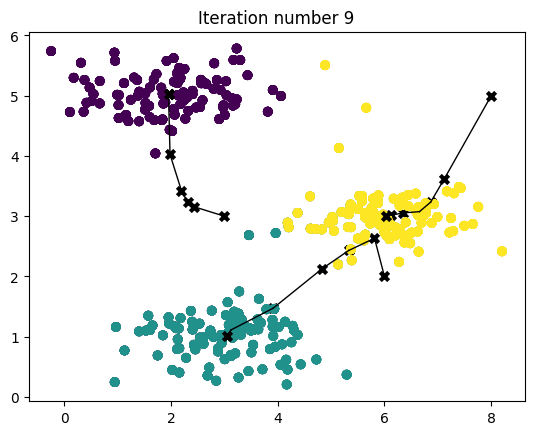

In [56]:
# Load an example dataset
X = load_data()

# Set initial centroids
initial_centroids = np.array([[3,3],[6,2],[8,5]])
K = 3

# Number of iterations
max_iters = 10

centroids, idx = run_kMeans(X, initial_centroids, max_iters, plot_progress=True)

<a name="3"></a>
## 3 - Random initialization

The initial assignments of centroids for the example dataset was designed so that you will see the same figure as in Figure 1. In practice, a good strategy for initializing the centroids is to select random examples from the
training set.

In this part of the exercise, you should understand how the function `kMeans_init_centroids` is implemented.
* The code first randomly shuffles the indices of the examples (using `np.random.permutation()`).
* Then, it selects the first $K$ examples based on the random permutation of the indices.
    * This allows the examples to be selected at random without the risk of selecting the same example twice.

**Note**: You do not need to make implement anything for this part of the exercise.

In [57]:
# You do not need to modify this part

def kMeans_init_centroids(X, K):
    """
    This function initializes K centroids that are to be
    used in K-Means on the dataset X

    Args:
        X (ndarray): Data points
        K (int):     number of centroids/clusters

    Returns:
        centroids (ndarray): Initialized centroids
    """

    # Randomly reorder the indices of examples
    randidx = np.random.permutation(X.shape[0])

    # Take the first K examples as centroids
    centroids = X[randidx[:K]]

    return centroids

<a name="4"></a>
## 4 - Image compression with K-means

In this exercise, you will apply K-means to image compression.

* In a straightforward 24-bit color representation of an image$^{2}$, each pixel is represented as three 8-bit unsigned integers (ranging from 0 to 255) that specify the red, green and blue intensity values. This encoding is often refered to as the RGB encoding.
* Our image contains thousands of colors, and in this part of the exercise, you will reduce the number of
colors to 16 colors.
* By making this reduction, it is possible to represent (compress) the photo in an efficient way.
* Specifically, you only need to store the RGB values of the 16 selected colors, and for each pixel in the image you now need to only store the index of the color at that location (where only 4 bits are necessary to represent 16 possibilities).

In this part, you will use the K-means algorithm to select the 16 colors that will be used to represent the compressed image.
* Concretely, you will treat every pixel in the original image as a data example and use the K-means algorithm to find the 16 colors that best group (cluster) the pixels in the 3- dimensional RGB space.
* Once you have computed the cluster centroids on the image, you will then use the 16 colors to replace the pixels in the original image.

<img src="images/figure 2.png" width="500" height="500">

$^{2}$<sub>The provided photo used in this exercise belongs to Frank Wouters and is used with his permission.</sub>

<a name="4.1"></a>
### 4.1 Dataset

**Load image**

First, you will use `matplotlib` to read in the original image, as shown below.

In [58]:
# Load an image of a bird
original_img = plt.imread('bird_small.png')

**Visualize image**

You can visualize the image that was just loaded using the code below.

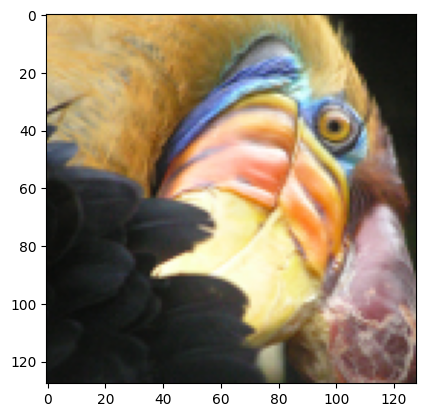

In [59]:
# Visualizing the image
plt.imshow(original_img)

**Check the dimension of the variable**

As always, you will print out the shape of your variable to get more familiar with the data.

In [60]:
print("Shape of original_img is:", original_img.shape)

Shape of original_img is: (128, 128, 3)


As you can see, this creates a three-dimensional matrix `original_img` where
* the first two indices identify a pixel position, and
* the third index represents red, green, or blue.

For example, `original_img[50, 33, 2]` gives the blue intensity of the pixel at row 50 and column 33.

#### Processing data

To call the `run_kMeans`, you need to first transform the matrix `original_img` into a two-dimensional matrix.

* The code below reshapes the matrix `original_img` to create an $m \times 3$ matrix of pixel colors (where
$m=16384 = 128\times128$)

In [61]:
# Divide by 255 so that all values are in the range 0 - 1
original_img = original_img / 255

# Reshape the image into an m x 3 matrix where m = number of pixels
# (in this case m = 128 x 128 = 16384)
# Each row will contain the Red, Green and Blue pixel values
# This gives us our dataset matrix X_img that we will use K-Means on.

X_img = np.reshape(original_img, (original_img.shape[0] * original_img.shape[1], 3))

<a name="4.2"></a>
### 4.2 K-Means on image pixels

Now, run the cell below to run K-Means on the pre-processed image.

In [62]:
# Run your K-Means algorithm on this data
# You should try different values of K and max_iters here

#Try different K values
K = 16
max_iters = 10

# Using the function you have implemented above.
initial_centroids = kMeans_init_centroids(X_img, K)

# Run K-Means - this takes a couple of minutes
centroids, idx = run_kMeans(X_img, initial_centroids, max_iters)

K-Means iteration 0/9
K-Means iteration 1/9
K-Means iteration 2/9
K-Means iteration 3/9
K-Means iteration 4/9
K-Means iteration 5/9
K-Means iteration 6/9
K-Means iteration 7/9
K-Means iteration 8/9
K-Means iteration 9/9


In [63]:
print("Shape of idx:", idx.shape)
print("Closest centroid for the first five elements:", idx[:5])

Shape of idx: (16384,)
Closest centroid for the first five elements: [0 0 0 0 0]


<a name="4.3"></a>
### 4.3 Compress the image


After finding the top $K=16$ colors to represent the image, you can now
assign each pixel position to its closest centroid using the
`find_closest_centroids` function.
* This allows you to represent the original image using the centroid assignments of each pixel.
* Notice that you have significantly reduced the number of bits that are required to describe the image.
    * The original image required 24 bits for each one of the $128\times128$ pixel locations, resulting in total size of $128 \times 128 \times 24 = 393,216$ bits.
    * The new representation requires some overhead storage in form of a dictionary of 16 colors, each of which require 24 bits, but the image itself then only requires 4 bits per pixel location.
    * The final number of bits used is therefore $16 \times 24 + 128 \times 128 \times 4 = 65,920$ bits, which corresponds to compressing the original image by about a factor of 6.

In [64]:
# Represent image in terms of indices
X_recovered = centroids[idx, :]

# Reshape recovered image into proper dimensions
X_recovered = np.reshape(X_recovered, original_img.shape)

Finally, you can view the effects of the compression by reconstructing
the image based only on the centroid assignments.
* Specifically, you can replace each pixel location with the mean of the centroid assigned to
it.
* Figure 3 shows the reconstruction we obtained. Even though the resulting image retains most of the characteristics of the original, we also see some compression artifacts.

<img src="images/figure 3.png" width="700" height="700">


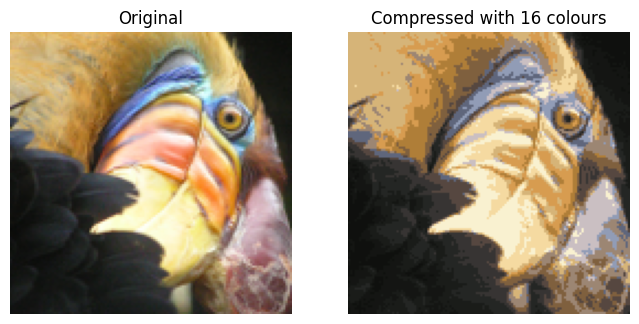

In [65]:
# Display original image
fig, ax = plt.subplots(1,2, figsize=(8,8))
plt.axis('off')

ax[0].imshow(original_img*255)
ax[0].set_title('Original')
ax[0].set_axis_off()


# Display compressed image
ax[1].imshow(X_recovered*255)
ax[1].set_title('Compressed with %d colours'%K)
ax[1].set_axis_off()

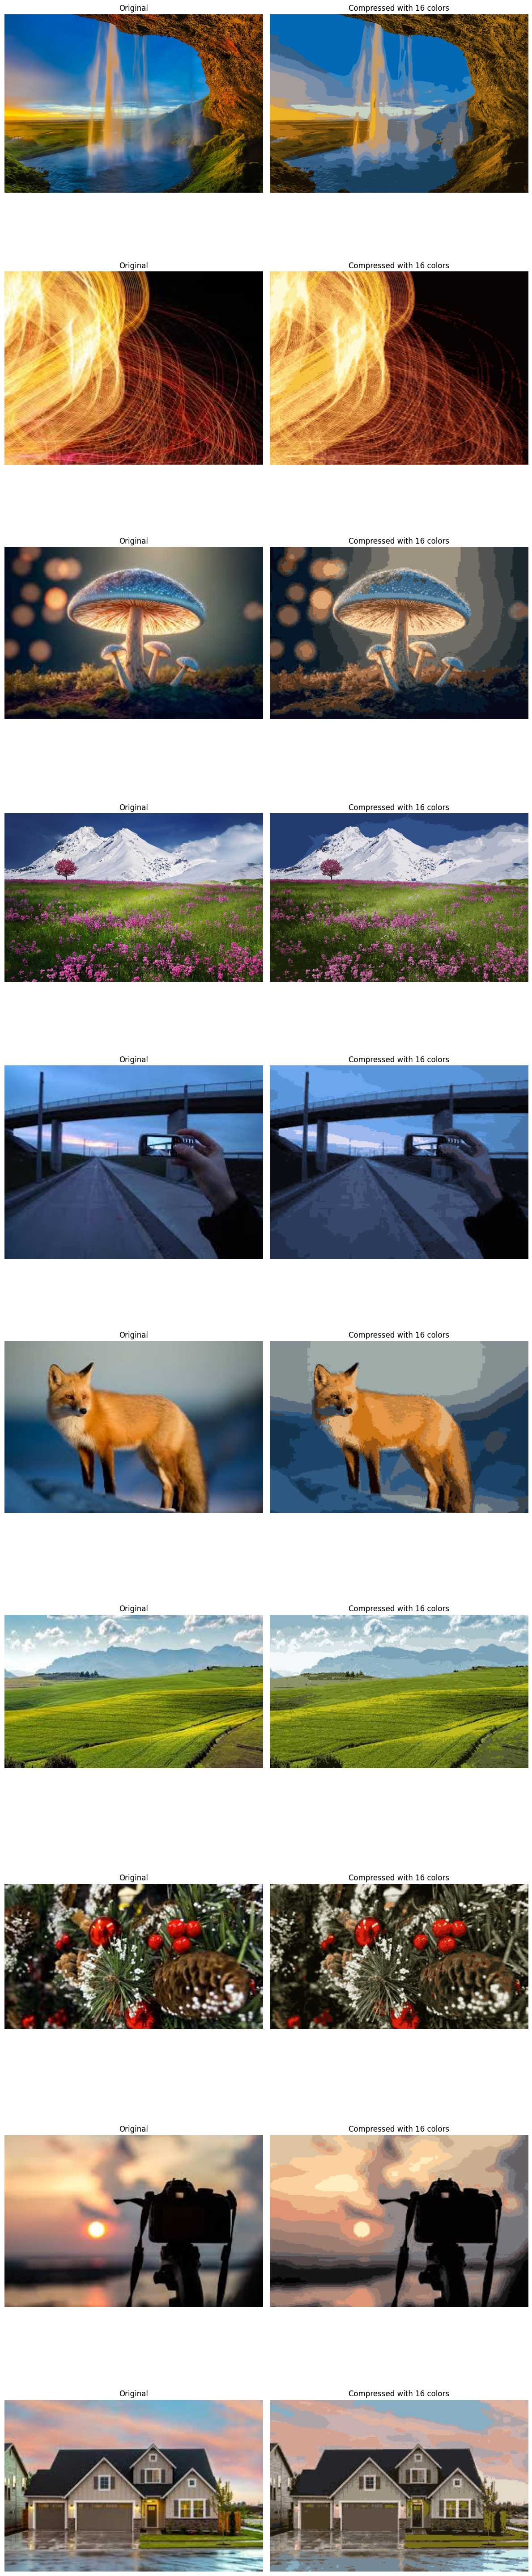

In [66]:
#your job is to run the compression on 10+ images of your choice
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import os

# Function to compress an image using K-Means
def compress_image(image, k=16, max_iters=10):
    if image.max() > 1:
        normalized_img = image / 255.0
    else:
        normalized_img = image

    X_img = np.reshape(normalized_img, (normalized_img.shape[0] * normalized_img.shape[1], 3))

    kmeans = KMeans(n_clusters=k, max_iter=max_iters, random_state=0)
    kmeans.fit(X_img)

    X_recovered = kmeans.cluster_centers_[kmeans.labels_]
    X_recovered = np.reshape(X_recovered, normalized_img.shape)
    X_recovered = np.clip(X_recovered, 0, 1)

    return X_recovered

# List of images to compress (update paths as necessary)
image_filenames = [
    'scene1.jpeg',
    'scene2.jpeg',
    'scene3.jpeg',
    'scene4.jpg',
    'scene5.jpeg',
    'scene6.jpeg',
    'scene7.jpeg',
    'scene8.jpeg',
    'scene9.jpeg',
    'scene10.jpeg'
]

# Initialize the plot
fig, axes = plt.subplots(len(image_filenames), 2, figsize=(12, 6 * len(image_filenames)))

# Loop through each image
for i, filename in enumerate(image_filenames):
    original_img = plt.imread(filename)
    compressed_img = compress_image(original_img, k=16, max_iters=10)

    # Display original and compressed images
    axes[i, 0].imshow(original_img)
    axes[i, 0].set_title('Original')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(compressed_img)
    axes[i, 1].set_title('Compressed with 16 colors')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()


### 1. Understanding Image Compression Techniques

- Explain the method used in this notebook to compress images. Why is it effective in reducing file size?
- What are the potential downsides of using this method to compress images?

 K-Means clustering is used for image compression, it reduces the amount of unique colours in the image. This works by first converting the image data to a two-dimensional format, with each pixel's colour information represented as a point in a 3-d colour space (with R, G, and B channels). The K-Means algorithm then separates similar colours into clusters, by a centroid (average colour) for that group. By replacing the colour of each pixel with the colour of the nearest centroid, we may reduce the number of unique colours in the image.This gives a compressed image that uses less storage.


It limits the image's colour palette while maintaining the overall colour distribution. Instead of saving each pixel's unique colour, we just need to save the index of the nearest centroid, which reduces the amount of bits necessary.
Original representation: 128 × 128 × 24 bits = 393,216 bits.
Compressed representation: 128 × 128 × 4 bits (for pixel indices) + 16 × 24 bits (for the centroid colors) = 65,920 bits.

**DOWNSIDE**

The disadvantages of implementing K-Means clustering for picture reduction include loss of colour detail and the development of artefacts. Because many colours are approximated by a single centroid colour, small details and minor colour variations in the image are lost, resulting in an image that seems blurry and simplified.





### 2. Evaluation of Compression

- Compare the quality of the compressed images with the original images. How do different values of $K$ (number of colors) affect the quality?
- Quantify the file size reduction achieved through this compression method. Is there a significant reduction in size?

Shape of original_img is: (128, 128, 3)
K-Means iteration 0/9
K-Means iteration 1/9
K-Means iteration 2/9
K-Means iteration 3/9
K-Means iteration 4/9
K-Means iteration 5/9
K-Means iteration 6/9
K-Means iteration 7/9
K-Means iteration 8/9
K-Means iteration 9/9


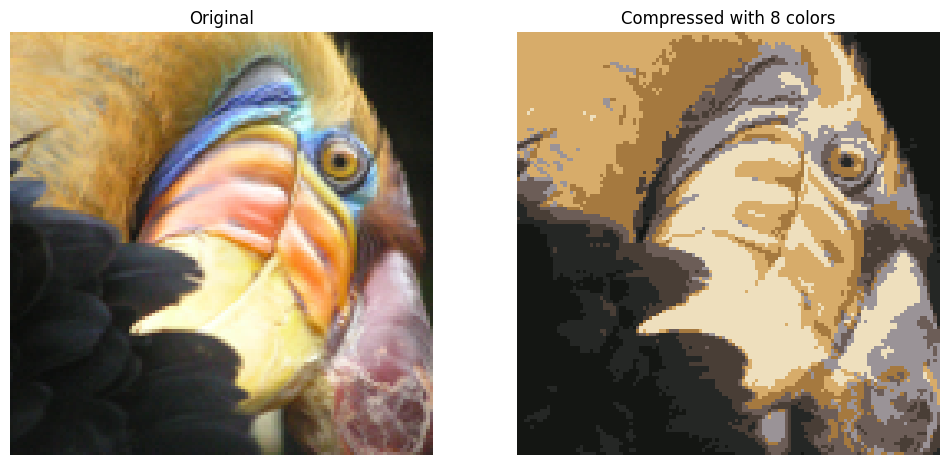

In [72]:

# Load the image
original_img = plt.imread('bird_small.png')
print("Shape of original_img is:", original_img.shape)

if original_img.max() > 1:
    normalized_img = original_img / 255.0
else:
    normalized_img = original_img

X_img = np.reshape(normalized_img, (normalized_img.shape[0] * normalized_img.shape[1], 3))

# Try different K values
K = 8
max_iters = 10

# Initialize centroids
initial_centroids = kMeans_init_centroids(X_img, K)

# Run K-Means
centroids, idx = run_kMeans(X_img, initial_centroids, max_iters)

# Recover image from the centroids and indices
X_recovered = centroids[idx, :]

# Reshape recovered image into proper dimensions
X_recovered = np.reshape(X_recovered, original_img.shape)

# Display original image
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(original_img)
ax[0].set_title('Original')
ax[0].axis('off')

# Display compressed image
ax[1].imshow(X_recovered)
ax[1].set_title('Compressed with %d colors' % K)
ax[1].axis('off')

plt.show()

Shape of original_img is: (182, 277, 3)
K-Means iteration 0/9
K-Means iteration 1/9
K-Means iteration 2/9
K-Means iteration 3/9
K-Means iteration 4/9
K-Means iteration 5/9
K-Means iteration 6/9
K-Means iteration 7/9
K-Means iteration 8/9
K-Means iteration 9/9


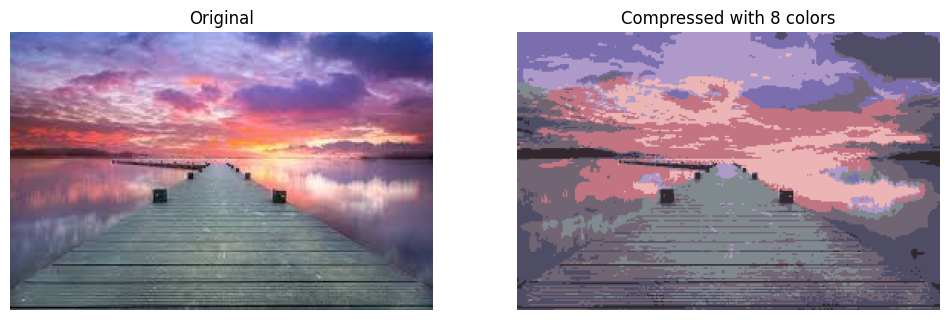

In [73]:

# Load the image
original_img = plt.imread('scene.jpeg')
print("Shape of original_img is:", original_img.shape)

if original_img.max() > 1:
    normalized_img = original_img / 255.0
else:
    normalized_img = original_img

X_img = np.reshape(normalized_img, (normalized_img.shape[0] * normalized_img.shape[1], 3))

# Try different K values
K = 8
max_iters = 10

# Initialize centroids
initial_centroids = kMeans_init_centroids(X_img, K)

# Run K-Means
centroids, idx = run_kMeans(X_img, initial_centroids, max_iters)

# Recover image from the centroids and indices
X_recovered = centroids[idx, :]

# Reshape recovered image into proper dimensions
X_recovered = np.reshape(X_recovered, original_img.shape)

# Display original image
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(original_img)
ax[0].set_title('Original')
ax[0].axis('off')

# Display compressed image
ax[1].imshow(X_recovered)
ax[1].set_title('Compressed with %d colors' % K)
ax[1].axis('off')

plt.show()

When we use k means clustering for image compression, the image quality highly relies on the value of K. As K increases, more colors are used to represent the image, making the compressed version closer to the original as analysed by my above examples with k=8, k=16 and k=22. We notice that as k increases more image colors are restored and similiar to the original image.



**File Size reduction**



Original file size=16,384×24=393,216 bits

Compressed file size=(Number of pixels×Bits per index)+(Number of centroids×Bits per centroid)





For
K=16:
Bits per index:
log
⁡
2
(
16
)
=
4
log
2
​
 (16)=4 bits.

Centroid storage:
16
×
24
=
384
16×24=384 bits.

Thus, the compressed file size is:

Compressed file size
=
(
16
,
384
×
4
)
+
384
=
65
,
920
 bits
Compressed file size=(16,384×4)+384=65,920 bits

Reduction Percentage:
Reduction
=
Original size
−
Compressed size
Original size
×
100

Reduction=
Original size
Original size−Compressed size
​
 ×100
=
393
,
216
−
65
,
920
393
,
216
×
100
≈
83.24
%
=
393,216
393,216−65,920
​
 ×100≈83.24%


For K=22:
Bits per index:
⌈
log
⁡
2
(
22
)
⌉
=
5
⌈log
2
​
 (22)⌉=5 bits.
Centroid storage:
22
×
24
=
528
22×24=528 bits.

Thus, the compressed file size is:


Compressed file size
=
(
16
,
384
×
5
)
+
528
=
81
,
728
 bits
Compressed file size=(16,384×5)+528=81,728 bits

Reduction Percentage:
Reduction
=
393
,
216
−
81
,
728
393
,
216
×
100
Reduction=
393,216
393,216−81,728
​
 ×100
≈
79.03
%
≈79.03%


We notice that as k increases, although the reduction percentage decreases but it is still significant as compared to the size of the original image.

### 3. Exploration of Different Images

- Test the compression algorithm on different types of images (e.g., nature scenes, portraits, graphics). How does the effectiveness of the compression vary across different types of images?

**Nature Scene**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

original_img = plt.imread('scene.jpeg')
print("Shape of original_img is:", original_img.shape)

if original_img.max() > 1:
    normalized_img = original_img / 255.0
else:
    normalized_img = original_img

X_img = np.reshape(normalized_img, (normalized_img.shape[0] * normalized_img.shape[1], 3))

K = 16
max_iters = 10

kmeans = KMeans(n_clusters=K, max_iter=max_iters, random_state=0)
kmeans.fit(X_img)

X_recovered = kmeans.cluster_centers_[kmeans.labels_]
X_recovered = np.reshape(X_recovered, normalized_img.shape)
X_recovered = np.clip(X_recovered, 0, 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(original_img)
ax[0].set_title('Original')
ax[0].axis('off')

ax[1].imshow(X_recovered)
ax[1].set_title(f'Compressed with {K} colours')
ax[1].axis('off')

plt.show()


**Portrait**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

original_img = plt.imread('portrait.jpeg')
print("Shape of original_img is:", original_img.shape)

if original_img.max() > 1:
    normalized_img = original_img / 255.0
else:
    normalized_img = original_img

X_img = np.reshape(normalized_img, (normalized_img.shape[0] * normalized_img.shape[1], 3))

K = 16
max_iters = 10

kmeans = KMeans(n_clusters=K, max_iter=max_iters, random_state=0)
kmeans.fit(X_img)

X_recovered = kmeans.cluster_centers_[kmeans.labels_]
X_recovered = np.reshape(X_recovered, normalized_img.shape)
X_recovered = np.clip(X_recovered, 0, 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(original_img)
ax[0].set_title('Original')
ax[0].axis('off')

ax[1].imshow(X_recovered)
ax[1].set_title(f'Compressed with {K} colours')
ax[1].axis('off')

plt.show()


**Graphics**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

original_img = plt.imread('graphics.jpeg')
print("Shape of original_img is:", original_img.shape)

if original_img.max() > 1:
    normalized_img = original_img / 255.0
else:
    normalized_img = original_img

X_img = np.reshape(normalized_img, (normalized_img.shape[0] * normalized_img.shape[1], 3))

K = 16
max_iters = 10

kmeans = KMeans(n_clusters=K, max_iter=max_iters, random_state=0)
kmeans.fit(X_img)

X_recovered = kmeans.cluster_centers_[kmeans.labels_]
X_recovered = np.reshape(X_recovered, normalized_img.shape)
X_recovered = np.clip(X_recovered, 0, 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(original_img)
ax[0].set_title('Original')
ax[0].axis('off')

ax[1].imshow(X_recovered)
ax[1].set_title(f'Compressed with {K} colours')
ax[1].axis('off')

plt.show()


From the above exploration,  the compression technique appears to be more efficient for natural, scenic photographs with broad colour palettes and less complex textures, as compared to portraits with finer face features and very detailed edges or graphics with complicated colour gradients.

### 4. Parameter Tuning

- Experiment with different values for the number of colors $K$. What is the optimal value for achieving a balance between compression and quality?

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

original_img = plt.imread('bird_small.png') / 255.0 if plt.imread('bird_small.png').max() > 1 else plt.imread('bird_small.png')
print("Shape of original_img is:", original_img.shape)

X_img = original_img.reshape(-1, 3)
K_values = [8, 16, 32, 64, 128]
max_iters = 20
original_img_display = original_img.copy()

def kMeans_init_centroids(X, K):
    indices = np.random.choice(X.shape[0], K, replace=False)
    return X[indices]

def run_kMeans(X, initial_centroids, max_iters):
    centroids = initial_centroids
    for _ in range(max_iters):
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
        idx = np.argmin(distances, axis=1)
        for k in range(K):
            points = X[idx == k]
            centroids[k] = np.mean(points, axis=0) if len(points) > 0 else centroids[k]
    return centroids, idx

for K in K_values:
    initial_centroids = kMeans_init_centroids(X_img, K)
    centroids, idx = run_kMeans(X_img, initial_centroids, max_iters)
    X_recovered = centroids[idx, :]
    X_recovered = np.reshape(X_recovered, original_img.shape)
    X_recovered = np.clip(X_recovered, 0, 1)
    num_pixels = original_img.shape[0] * original_img.shape[1]
    bits_per_index = int(np.ceil(np.log2(K)))
    compressed_size = (num_pixels * bits_per_index) + (K * 24)
    compression_ratio = 100 * (1 - compressed_size / (num_pixels * 24))

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(original_img_display)
    ax[0].set_title('Original')
    ax[0].axis('off')
    ax[1].imshow((X_recovered * 255).astype(np.uint8))
    ax[1].set_title(f'Compressed with {K} colors\nCompression: {compression_ratio:.2f}%')
    ax[1].axis('off')
    plt.show()


 The best number of colours (K) appears to be between 32 and 64. This range is a good balance  between compression efficiency (file size reduction) and preserving the  visual features and quality of the original image. The 32-color option may be a somewhat better compromise in circumstances where file size is more considerable, but the 64-color option is better suited for scenarios when image quality preservation is the top priority.

### 5. Advanced Compression Techniques

- Research and implement a different image compression technique (e.g., JPEG, wavelet-based compression). Compare the performance with the current approach.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Step 1: Load and Convert the Image to Grayscale
# Load an example image and convert to grayscale
original_img = Image.open('bird_small.png').convert('L')
original_img = np.array(original_img)

# Step 2: Run-Length Encoding (RLE) Compression
def rle_encode(image):
    # Flatten the image to a 1D array
    pixels = image.flatten()
    encoded_pixels = []
    count = 1

    # Perform Run-Length Encoding
    for i in range(1, len(pixels)):
        if pixels[i] == pixels[i - 1]:
            count += 1
        else:
            encoded_pixels.append((pixels[i - 1], count))
            count = 1

    # Append the last run
    encoded_pixels.append((pixels[-1], count))
    return encoded_pixels

# Step 3: RLE Decoding
def rle_decode(encoded_pixels, shape):
    decoded_image = []
    for value, count in encoded_pixels:
        decoded_image.extend([value] * count)

    # Reshape back to the original image dimensions
    return np.array(decoded_image).reshape(shape)

# Compress the image using RLE
encoded_data = rle_encode(original_img)

# Decompress the RLE data
decoded_img = rle_decode(encoded_data, original_img.shape)

# Step 4: Display the Original and Decoded (Decompressed) Image
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Display the original image
ax[0].imshow(original_img, cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')

# Display the decompressed image
ax[1].imshow(decoded_img, cmap='gray')
ax[1].set_title('RLE Decompressed Image')
ax[1].axis('off')

plt.show()


RLE is a lossless compression method that successfully decreases the size of images with broad sections of uniform colour by encoding successive pixel values and counts, resulting in a clear compression ratio while maintaining the original image quality perfectly during decompression. In contrast, KNN is a lossy approximation method that takes advantage of the spatial correlations of pixel values, predicting pixel values using the K nearest neighbours, lowering the number of unique colours and gaining great visual fidelity but perhaps losing some information. While RLE has a higher compression ratio for photos with repeating patterns, KNN  gives faster processing.

### 6. Real-World Application

- Discuss how this type of image compression is used in real-world applications (e.g., web image optimization, storage solutions). What are some alternatives?

For **websites**, image compression is an important technique for improving user experience and performance. When photos are compressed, web pages load faster, lowering bounce rates and increasing search engine rankings.

Lossy formats such as JPEG and WebP are commonly used for high-resolution photographs and images. They remove small features that the human eye cannot see, resulting in a huge reduction in file size.
Lossless Compression (PNG, WebP, and AVIF): Lossless formats like PNG are popular for images that require a high level of detail, such as logos or text drawings. They keep all originals.

**Image storage** in data centres can take up a lot of space, especially for high-resolution photos used in media, e-commerce, or science. Compression is critical for reducing storage requirements and lowering expenses.
JPEG versus JPEG 2000: JPEG is a common photo format, but JPEG 2000 provides higher quality at smaller file sizes and includes lossless settings.
Tagged Image File Format (TIFF): TIFF files, which are commonly used in archiving and medical imaging, are lossless and capable of storing exceedingly high-quality images, despite their size. Some TIFF versions, such as LZW, include compression to help manage file size.
HEIF (High Efficiency Image Format): Apple and other systems use HEIF, which is known for its efficient compression and high-quality results. It can handle more data per pixel than JPEG.

**Alternatives**

Progressive JPEG: This is a JPEG variant that loads images in numerous passes, allowing viewers to see a lower-quality version of the image first, which improves perceived loading time.


AI and Neural Network-Based Compression: Techniques like Google's RAISR (Rapid and Accurate Image Super Resolution) employ machine learning to upscale compressed images, allowing ultra-low storage and bandwidth.

### 7. Performance Metrics

- Develop and implement a method to measure the performance of the image compression in terms of both visual quality and computational efficiency.

# this part of code is taken help from google as told by TA.

KNN Compression - Time: 0.0520s, PSNR: 90.28 dB, SSIM: 1.0000


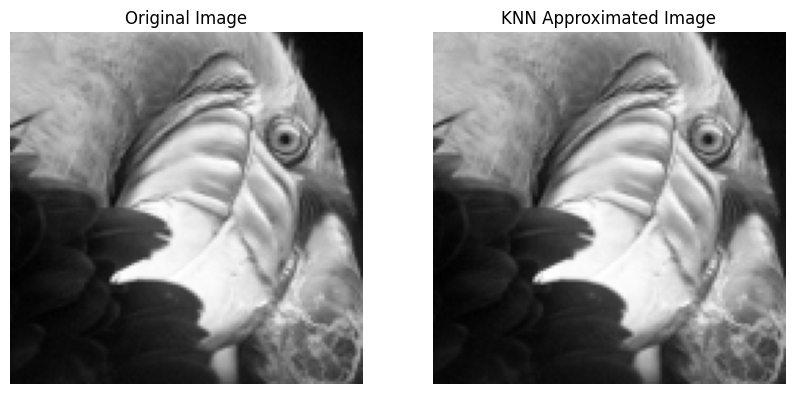

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.neighbors import KNeighborsRegressor
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim
import time

original_img = Image.open('bird_small.png').convert('L')
original_img = np.array(original_img)

def knn_image_approximation(image, n_neighbors=5):
    h, w = image.shape
    pixel_values = image.reshape(-1, 1)
    knn = KNeighborsRegressor(n_neighbors=n_neighbors)
    knn.fit(pixel_values, pixel_values)
    approximated_pixels = knn.predict(pixel_values).reshape(h, w)
    return approximated_pixels.astype(np.uint8)

def measure_knn_performance(original_img, n_neighbors=5):
    results = {}
    start_time = time.time()
    knn_approximated = knn_image_approximation(original_img, n_neighbors=n_neighbors)
    compression_time = time.time() - start_time
    knn_psnr = psnr(original_img, knn_approximated)
    knn_ssim = ssim(original_img, knn_approximated)
    results['Compression Time'] = compression_time
    results['PSNR'] = knn_psnr
    results['SSIM'] = knn_ssim
    return results, knn_approximated

knn_results, knn_approximated_img = measure_knn_performance(original_img, n_neighbors=5)

print(f"KNN Compression - Time: {knn_results['Compression Time']:.4f}s, PSNR: {knn_results['PSNR']:.2f} dB, SSIM: {knn_results['SSIM']:.4f}")

def visualize_results(original_img, knn_approximated_img):
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(original_img, cmap='gray')
    ax[0].set_title('Original Image')
    ax[0].axis('off')
    ax[1].imshow(knn_approximated_img, cmap='gray')
    ax[1].set_title('KNN Approximated Image')
    ax[1].axis('off')
    plt.show()

visualize_results(original_img, knn_approximated_img)
